/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Moviepy - Building video frozen_lake_simulation.mp4.
Moviepy - Writing video frozen_lake_simulation.mp4



Moviepy - Done !
Moviepy - video ready frozen_lake_simulation.mp4
Simulation saved as frozen_lake_simulation.mp4


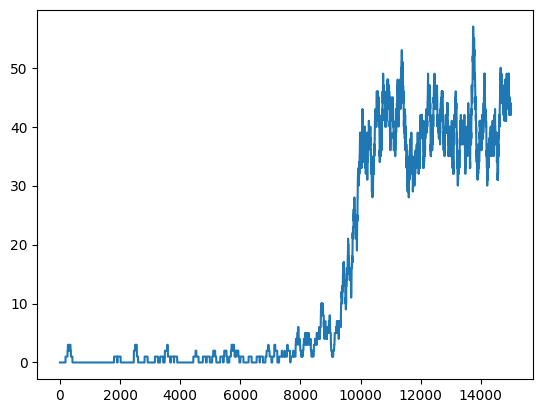

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
from PIL import Image # Import for GIF creation
from IPython.display import Image as IImage, display, Video # Import for displaying GIF and Video in Colab
from moviepy.editor import ImageSequenceClip # Import for video creation

def run(episodes, is_training=True, render=False):

    # Change render_mode to 'rgb_array' if rendering is requested
    render_mode = 'rgb_array' if render else None
    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=True, render_mode=render_mode)

    if(is_training):
        q = np.zeros((env.observation_space.n, env.action_space.n))
    else:
        # Ensure the file exists before attempting to load
        try:
            with open('frozen_lake8x8.pkl', 'rb') as f:
                q = pickle.load(f)
        except FileNotFoundError:
            print("Error: frozen_lake8x8.pkl not found. Please train the model first by running `run(15000, is_training=True)`")
            env.close()
            return

    learning_rate_a = 0.9 # alpha or learning rate
    discount_factor_g = 0.9 # gamma or discount rate. Near 0: more weight/reward placed on immediate state. Near 1: more on future state.
    epsilon = 1         # 1 = 100% random actions
    epsilon_decay_rate = 0.0001        # epsilon decay rate. 1/0.0001 = 10,000
    rng = np.random.default_rng()   # random number generator

    rewards_per_episode = np.zeros(episodes)

    frames = [] # List to store frames for GIF/Video creation

    for i in range(episodes):
        state = env.reset()[0]  # states: 0 to 63, 0=top left corner,63=bottom right corner
        terminated = False      # True when fall in hole or reached goal
        truncated = False       # True when actions > 200

        while(not terminated and not truncated):
            if render: # Capture frame if rendering is enabled
                frame = env.render()
                if frame is not None:
                    frames.append(frame) # Append numpy array directly

            if is_training and rng.random() < epsilon:
                action = env.action_space.sample() # actions: 0=left,1=down,2=right,3=up
            else:
                action = np.argmax(q[state,:])

            new_state,reward,terminated,truncated,_ = env.step(action)

            if is_training:
                q[state,action] = q[state,action] + learning_rate_a * (
                    reward + discount_factor_g * np.max(q[new_state,:]) - q[state,action]
                )

            state = new_state

        if render: # Capture final frame for the episode
            frame = env.render()
            if frame is not None:
                frames.append(frame)

        epsilon = max(epsilon - epsilon_decay_rate, 0)

        if(epsilon==0):
            learning_rate_a = 0.0001

        if reward == 1:
            rewards_per_episode[i] = 1

    env.close()

    sum_rewards = np.zeros(episodes)
    for t in range(episodes):
        sum_rewards[t] = np.sum(rewards_per_episode[max(0, t-100):(t+1)])
    plt.plot(sum_rewards)
    plt.savefig('frozen_lake8x8.png')

    if is_training:
        with open("frozen_lake8x8.pkl","wb") as f:
            pickle.dump(q, f)
    elif render and len(frames) > 0: # If not training, and render was True, save and display VIDEO
        video_path = 'frozen_lake_simulation.mp4'
        # Create an ImageSequenceClip from the collected frames (numpy arrays)
        clip = ImageSequenceClip(frames, fps=10) # Adjust fps as needed
        clip.write_videofile(video_path, codec='libx264', audio_codec='aac')
        print(f"Simulation saved as {video_path}")
        display(Video(video_path, embed=True, width=400))

if __name__ == '__main__':
    # 1. First, train the model to create 'frozen_lake8x8.pkl'
    run(15000, is_training=True, render=False) # Train without rendering

    # 2. Then, run a short simulation with the trained model
    run(5, is_training=False, render=True)